##### importing library pandas and numpy
#### house price dataset

In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv("123.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
df.shape

(1460, 81)

In [5]:
df.isna().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [6]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [7]:
for i in df.columns:
  if((df[i].dtype=="object")  and (df[i].isna().sum()>365)):
    df=df.drop(i,axis=1)

In [8]:
for i in df.columns:
  if(((df[i].dtype=="int64") or (df[i].dtype=="float64"))  and (df[i].isna().sum()>750)):
    df=df.drop(df[i],axis=1)

In [9]:
df.shape

(1460, 75)

In [10]:
for i in df.columns:
  if(((df[i].dtype=="int64") or (df[i].dtype=="float64"))  and (df[i].isna().sum()<750)):
    df[i]=df[i].fillna(df[i].median())

In [11]:
for i in df.columns:
  if((df[i].dtype=="object")  and (df[i].isna().sum()<370)):
    df[i]=df[i].fillna(df[i].mode()[0])

In [12]:
df.shape

(1460, 75)

In [13]:
df.isna().sum().sum()

np.int64(0)

In [14]:
obj_columns=df.select_dtypes(include="object").columns.tolist()
print(len(obj_columns))

37


In [15]:

# check unique values per object column BEFORE encoding
obj_cols = df.select_dtypes(include="object").columns

for col in obj_cols:
    print(f"{col} → {df[col].nunique()} categories: {df[col].unique()}")

MSZoning → 5 categories: ['RL' 'RM' 'C (all)' 'FV' 'RH']
Street → 2 categories: ['Pave' 'Grvl']
LotShape → 4 categories: ['Reg' 'IR1' 'IR2' 'IR3']
LandContour → 4 categories: ['Lvl' 'Bnk' 'Low' 'HLS']
Utilities → 2 categories: ['AllPub' 'NoSeWa']
LotConfig → 5 categories: ['Inside' 'FR2' 'Corner' 'CulDSac' 'FR3']
LandSlope → 3 categories: ['Gtl' 'Mod' 'Sev']
Neighborhood → 25 categories: ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']
Condition1 → 9 categories: ['Norm' 'Feedr' 'PosN' 'Artery' 'RRAe' 'RRNn' 'RRAn' 'PosA' 'RRNe']
Condition2 → 8 categories: ['Norm' 'Artery' 'RRNn' 'Feedr' 'PosN' 'PosA' 'RRAn' 'RRAe']
BldgType → 5 categories: ['1Fam' '2fmCon' 'Duplex' 'TwnhsE' 'Twnhs']
HouseStyle → 8 categories: ['2Story' '1Story' '1.5Fin' '1.5Unf' 'SFoyer' 'SLvl' '2.5Unf' '2.5Fin']
RoofStyle → 

In [16]:
from sklearn.preprocessing import LabelEncoder

In [17]:
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   int64  
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   int64  
 6   LotShape       1460 non-null   int64  
 7   LandContour    1460 non-null   int64  
 8   Utilities      1460 non-null   int64  
 9   LotConfig      1460 non-null   int64  
 10  LandSlope      1460 non-null   int64  
 11  Neighborhood   1460 non-null   int64  
 12  Condition1     1460 non-null   int64  
 13  Condition2     1460 non-null   int64  
 14  BldgType       1460 non-null   int64  
 15  HouseStyle     1460 non-null   int64  
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [19]:
correllation=df.corr()
correllation

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,1.000000,0.011156,-0.006096,-0.009921,-0.033226,0.008916,0.032122,-0.019659,0.013324,0.049756,...,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,0.019773,-0.005806,-0.021917
MSSubClass,0.011156,1.000000,0.035900,-0.356718,-0.139781,-0.024969,0.119289,-0.002940,-0.022844,0.075910,...,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,0.012464,-0.024940,-0.084284
MSZoning,-0.006096,0.035900,1.000000,-0.105961,-0.034452,0.087654,0.061887,-0.017854,-0.001192,-0.009895,...,0.115509,0.000362,0.019089,-0.003128,0.009293,-0.031496,-0.020628,0.097437,0.009494,-0.166872
LotFrontage,-0.009921,-0.356718,-0.105961,1.000000,0.304522,-0.037349,-0.138877,-0.076080,-0.001027,-0.177821,...,0.010287,0.061945,0.037655,0.180819,-0.000255,0.010451,0.006380,-0.031412,0.058857,0.334771
LotArea,-0.033226,-0.139781,-0.034452,0.304522,1.000000,-0.197131,-0.165315,-0.149083,0.010123,-0.121161,...,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.012292,0.034169,0.263843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MoSold,0.021172,-0.013585,-0.031496,0.010451,0.001205,0.003690,-0.033455,-0.011599,-0.051552,0.018902,...,-0.028887,0.029474,0.023217,-0.033737,-0.006495,1.000000,-0.145721,-0.047386,0.013320,0.046432
YrSold,0.000712,-0.021407,-0.020628,0.006380,-0.014261,-0.025043,0.036449,0.020507,0.023353,-0.005992,...,-0.009916,0.018645,0.010694,-0.059689,0.004906,-0.145721,1.000000,-0.002327,0.003880,-0.028923
SaleType,0.019773,0.012464,0.097437,-0.031412,0.012292,0.014339,-0.000911,-0.025754,-0.126770,0.014325,...,-0.016731,-0.009034,0.004533,0.011009,0.015773,-0.047386,-0.002327,1.000000,0.184067,-0.054911
SaleCondition,-0.005806,-0.024940,0.009494,0.058857,0.034169,0.006064,-0.038118,0.033809,-0.089701,0.051579,...,-0.098388,0.004379,-0.020095,-0.067251,0.013027,0.013320,0.003880,0.184067,1.000000,0.213092


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

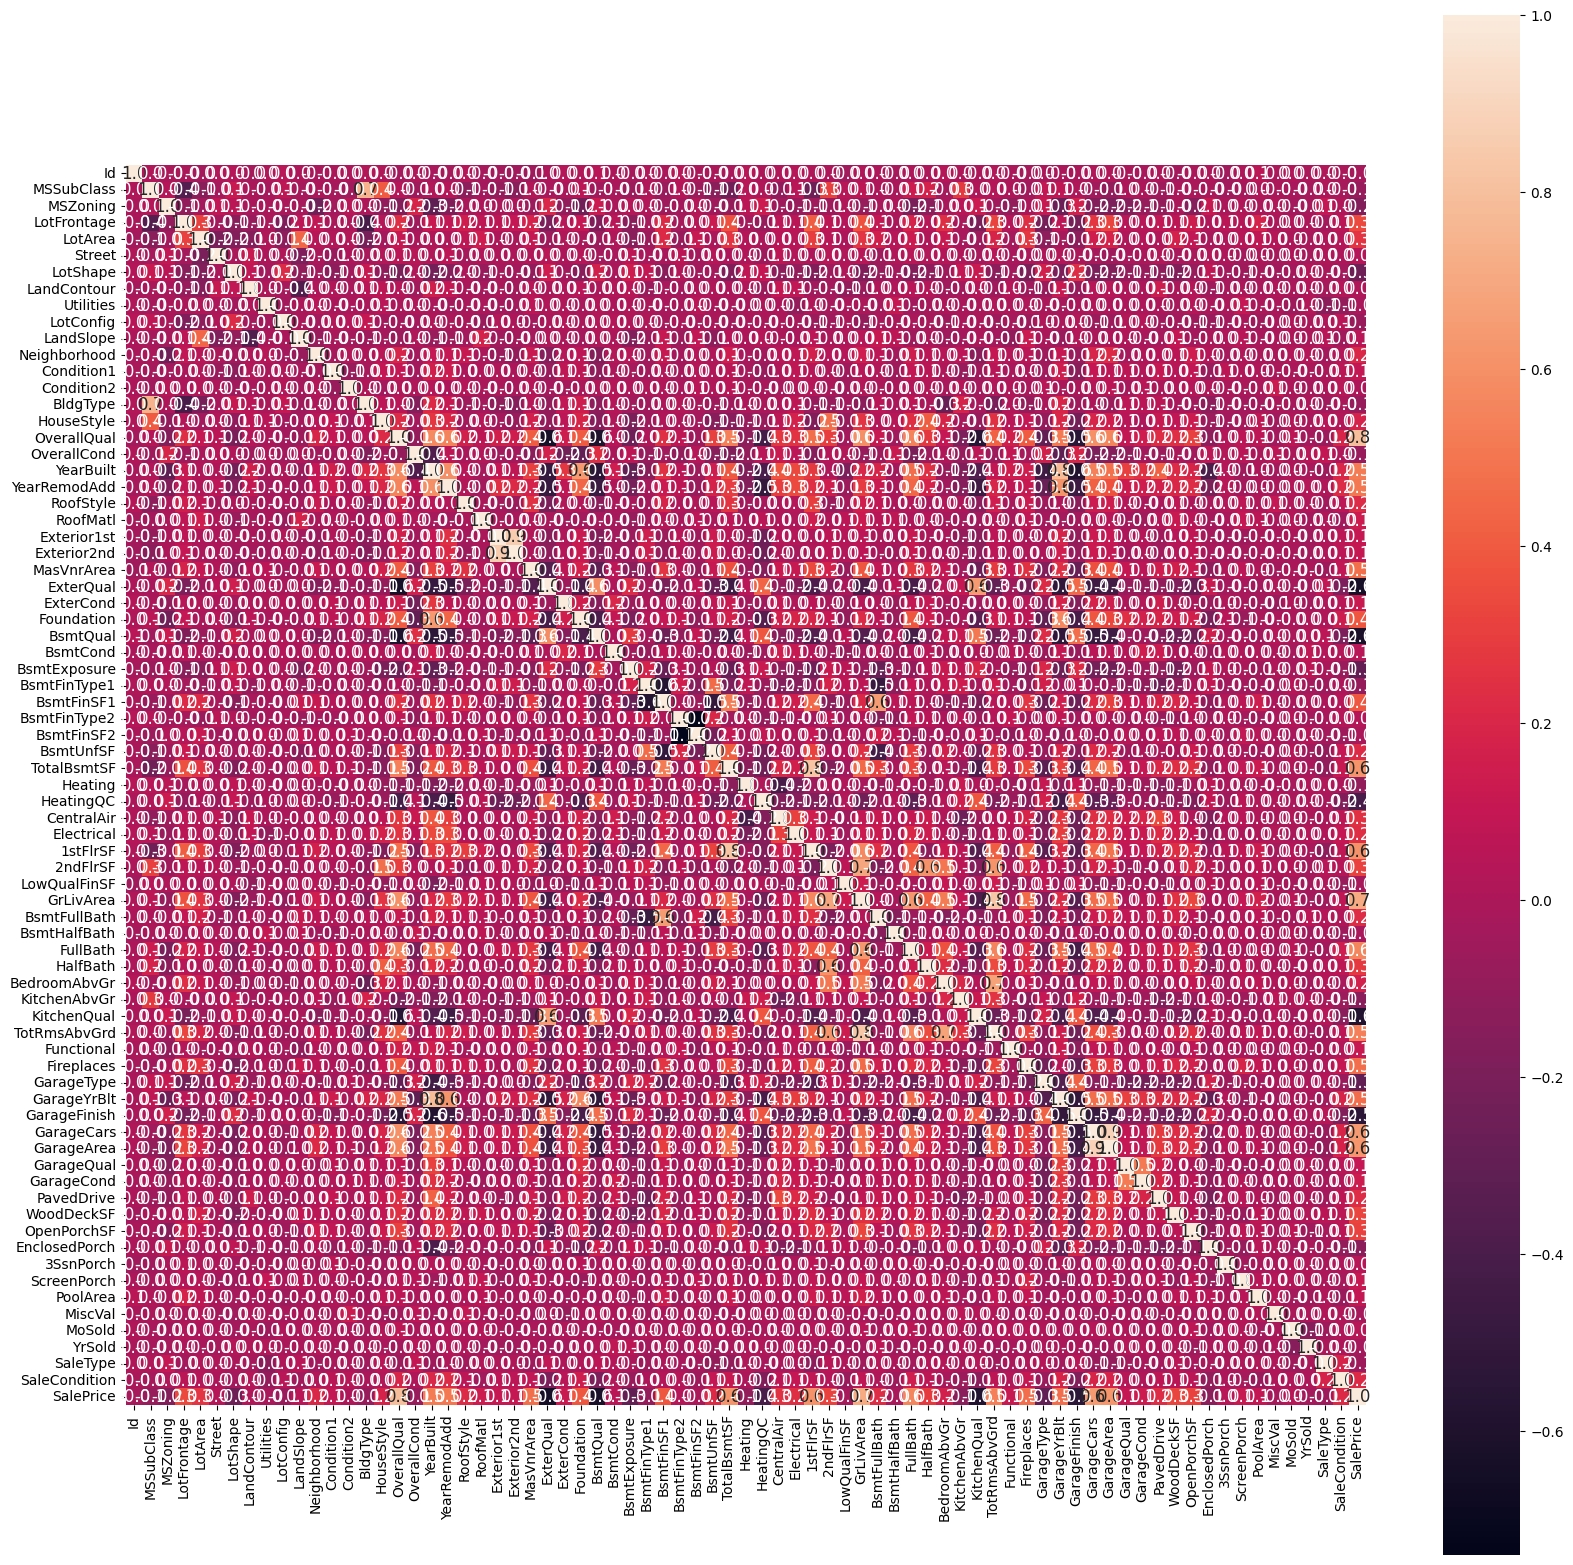

In [21]:
plt.figure(figsize=(20,20))
sns.heatmap(correllation, square=True, fmt='.1f',annot=True, annot_kws={'size':12})

In [22]:
G1 = df.iloc[:, :10]
G2 = df.iloc[:, 10:20]
G3 = df.iloc[:, 20:30]
G4 = df.iloc[:, 30:40]
G5 = df.iloc[:, 40:50]
G6 = df.iloc[:, 50:60]
G7 = df.iloc[:, 60:70]
G8 = df.iloc[:,70:]

#### droping those column which have 5 zero or more zero accept those who can help in predction

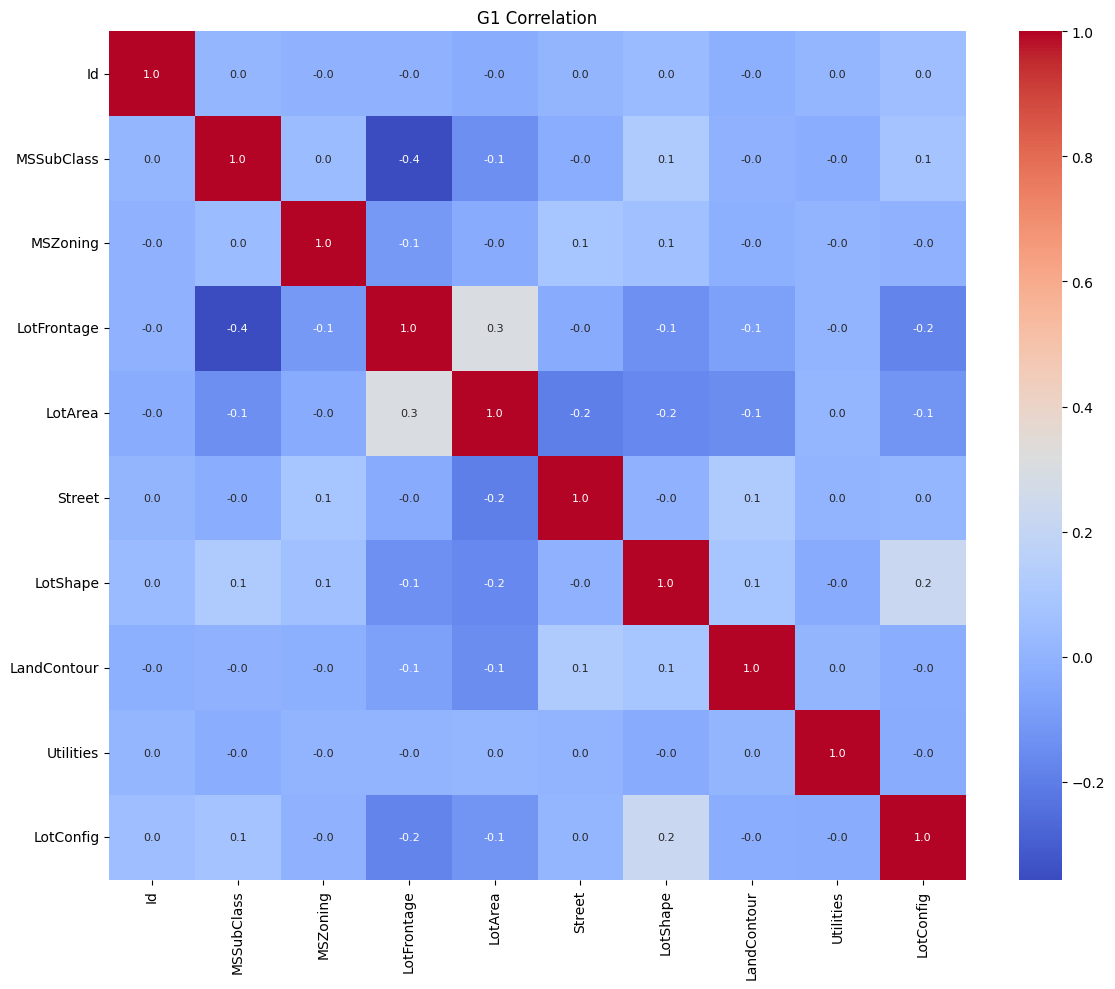

In [23]:
plt.figure(figsize=(12, 10))
sns.heatmap(G1.corr(), annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 8})
plt.title("G1 Correlation")
plt.tight_layout()
plt.show()

In [24]:
df=df.drop(["Id","Street","LandContour","Utilities","LotConfig"],axis=1)

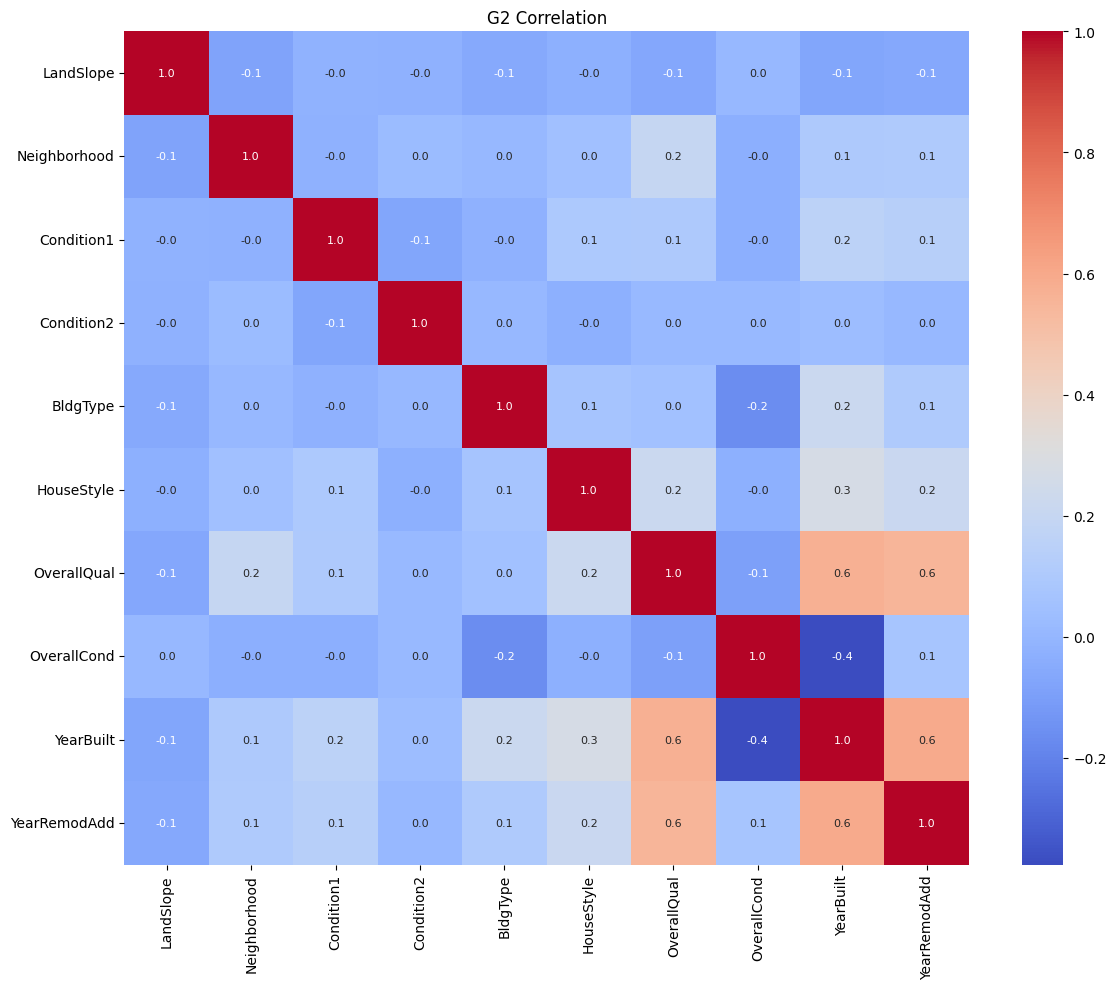

In [25]:
plt.figure(figsize=(12, 10))
sns.heatmap(G2.corr(), annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 8})
plt.title("G2 Correlation")
plt.tight_layout()
plt.show()

In [26]:
df=df.drop(["Condition2","Neighborhood"],axis=1)

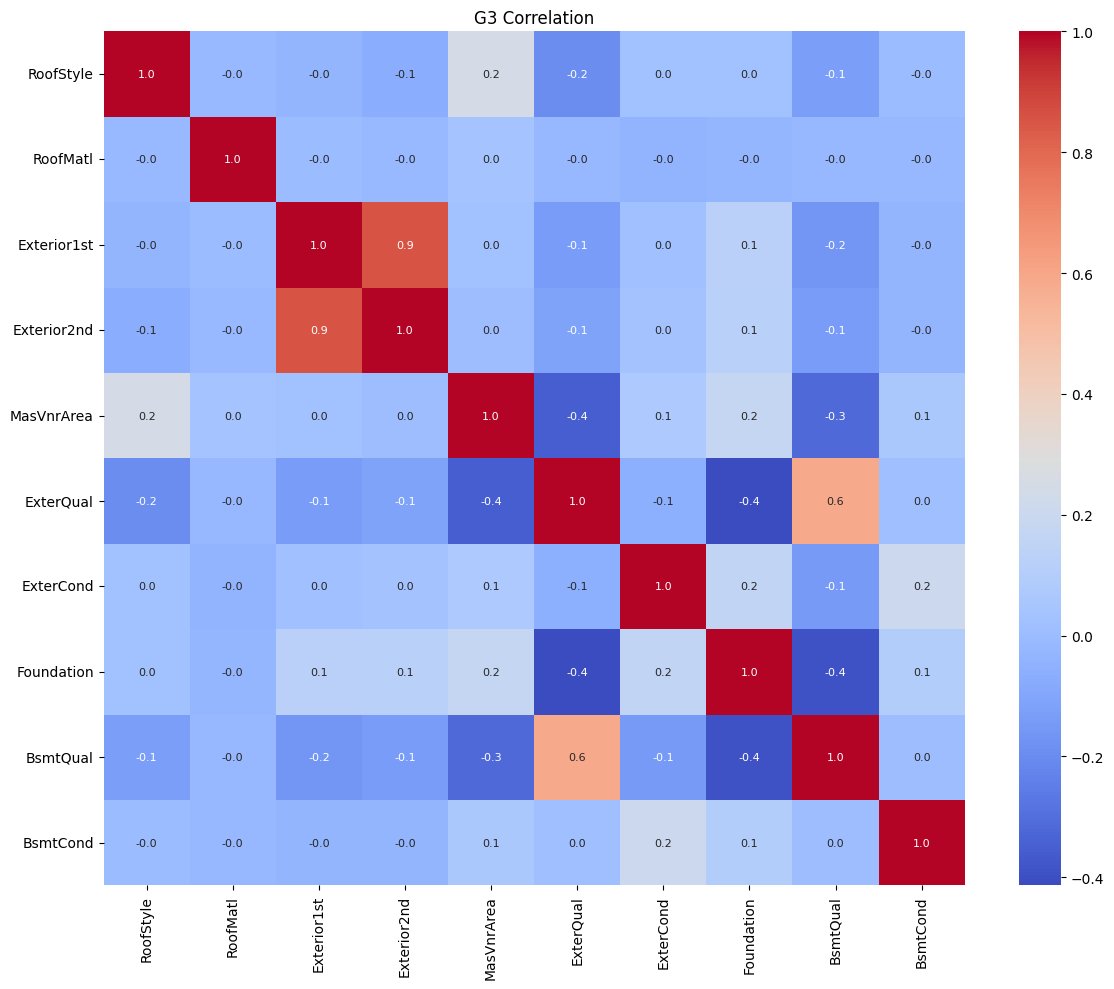

In [27]:
plt.figure(figsize=(12, 10))
sns.heatmap(G3.corr(), annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 8})
plt.title("G3 Correlation")
plt.tight_layout()
plt.show()

In [28]:
df=df.drop(["RoofStyle","RoofMatl","Exterior1st","BsmtCond"],axis=1)

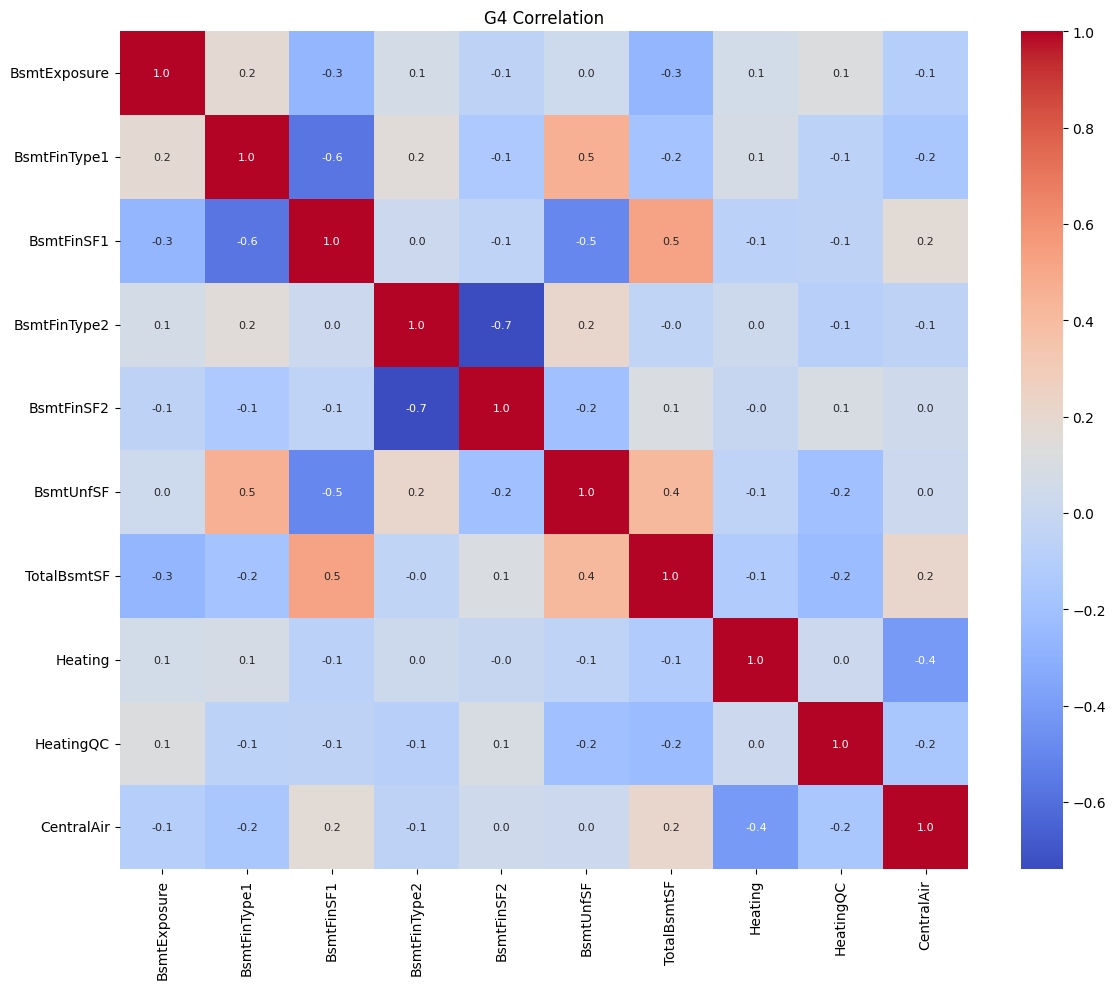

In [29]:
plt.figure(figsize=(12, 10))
sns.heatmap(G4.corr(), annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 8})
plt.title("G4 Correlation")
plt.tight_layout()
plt.show()

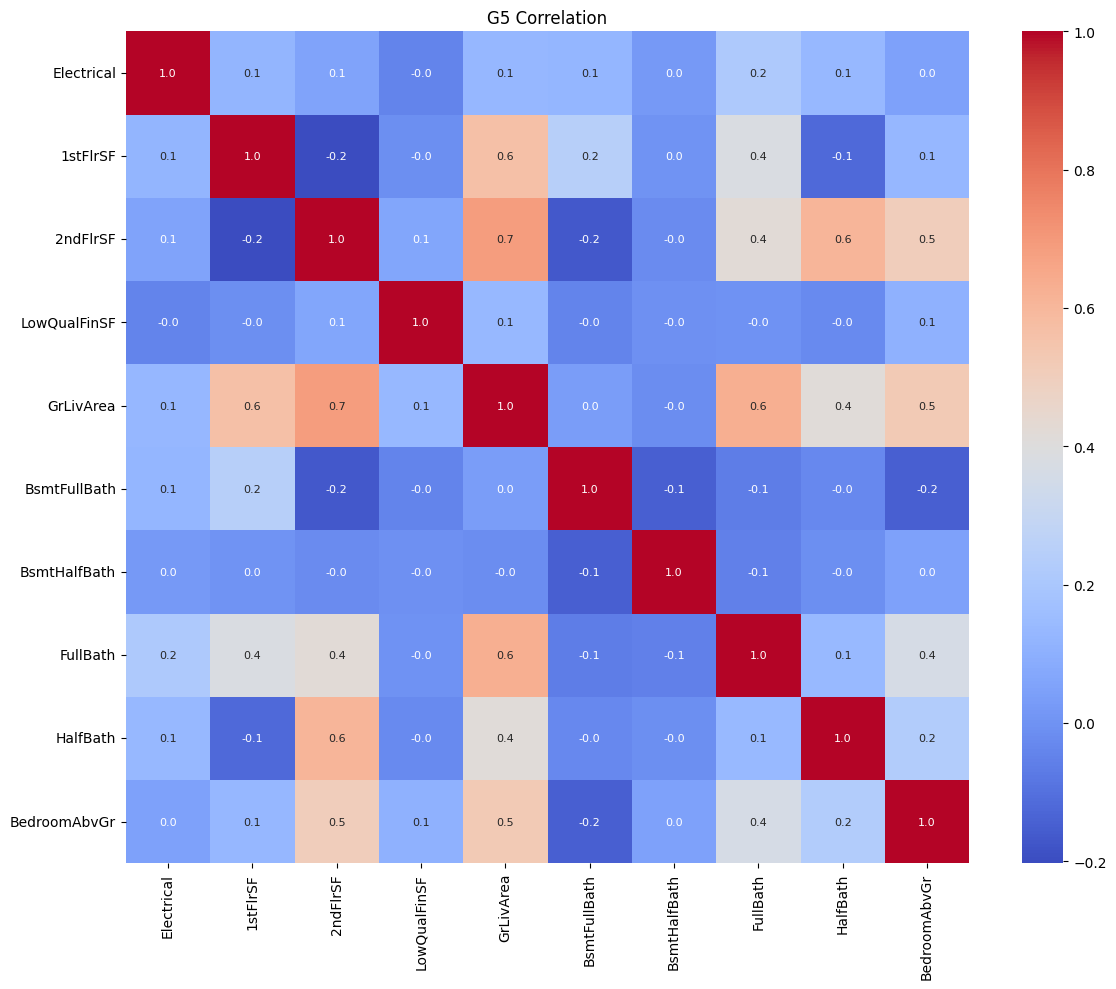

In [30]:
plt.figure(figsize=(12, 10))
sns.heatmap(G5.corr(), annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 8})
plt.title("G5 Correlation")
plt.tight_layout()
plt.show()

In [31]:
df=df.drop(["LowQualFinSF","BsmtHalfBath"],axis=1)

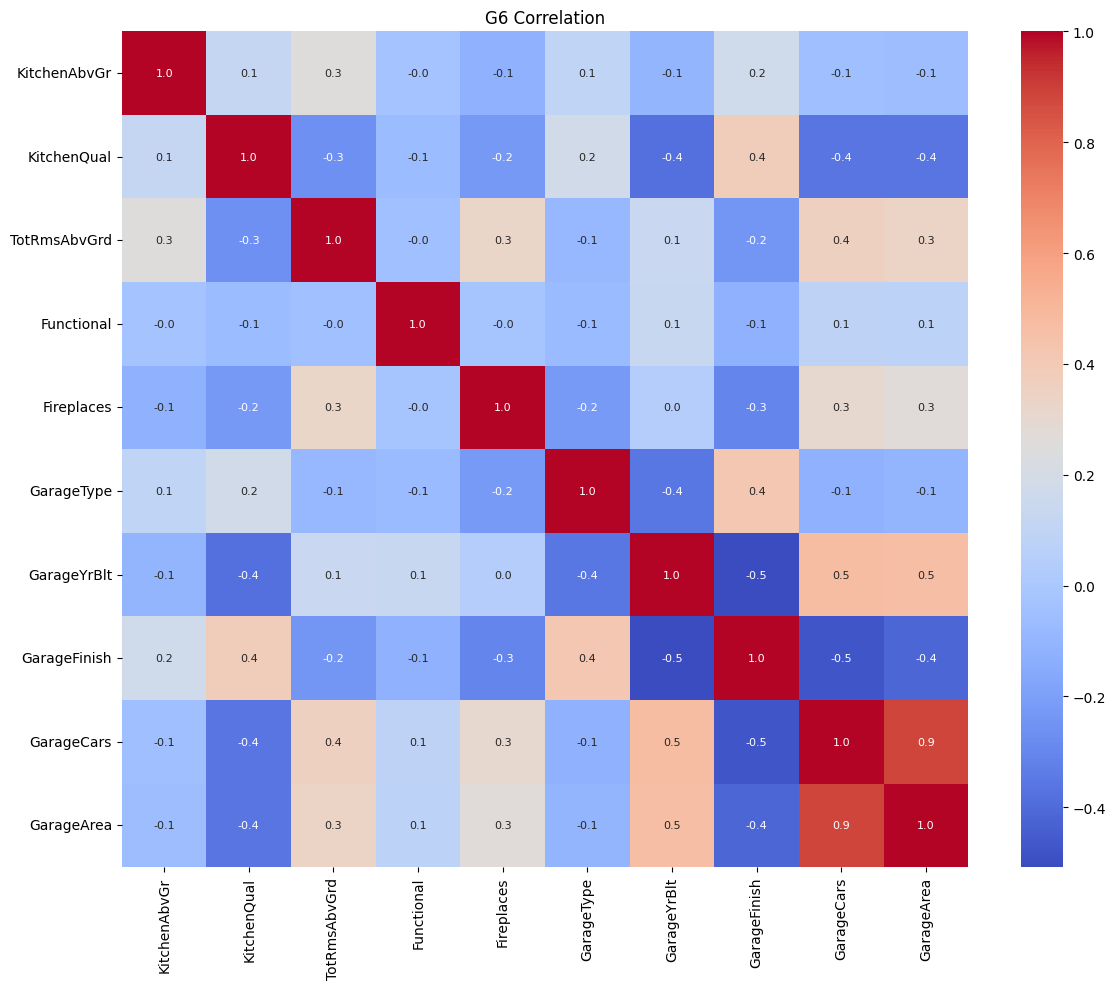

In [32]:
plt.figure(figsize=(12, 10))
sns.heatmap(G6.corr(), annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 8})
plt.title("G6 Correlation")
plt.tight_layout()
plt.show()

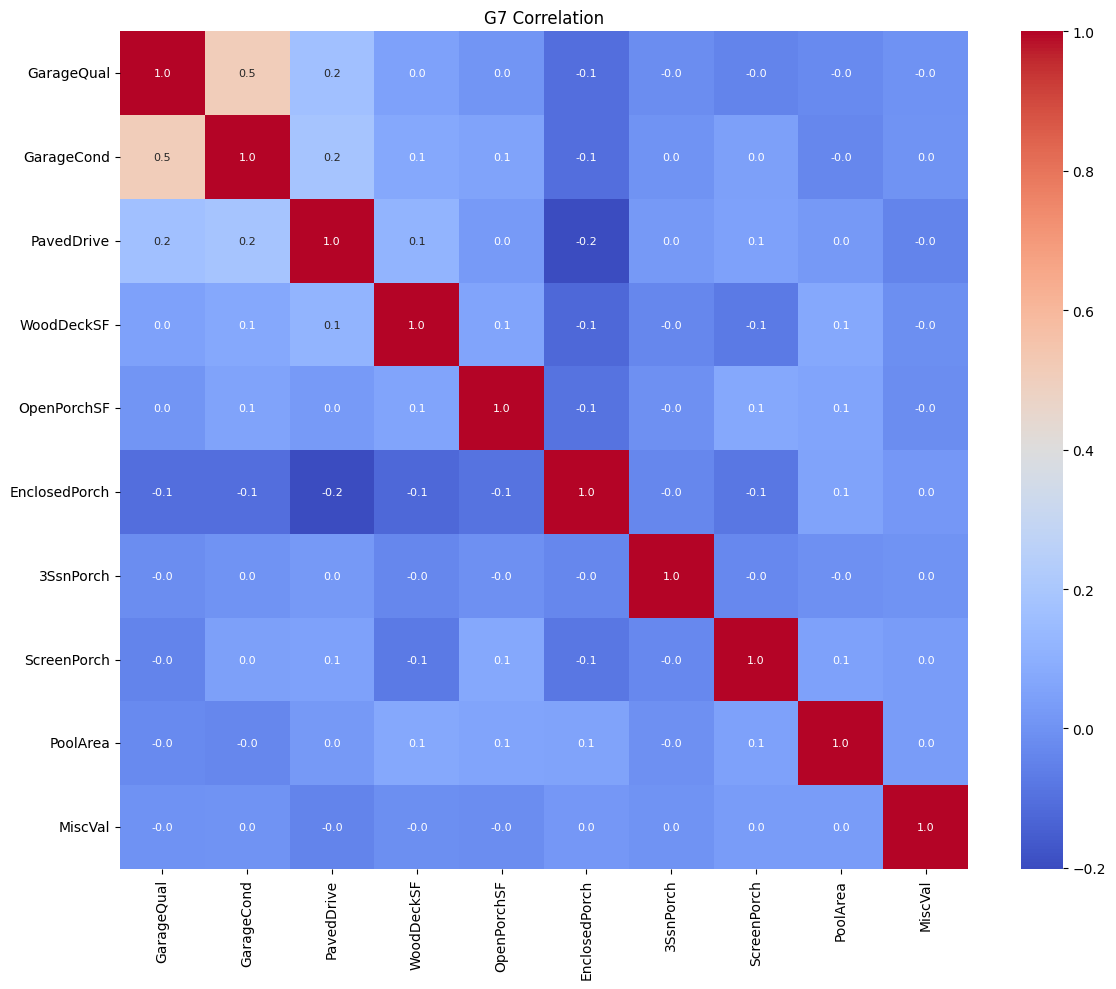

In [33]:
plt.figure(figsize=(12, 10))
sns.heatmap(G7.corr(), annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 8})
plt.title("G7 Correlation")
plt.tight_layout()
plt.show()

In [34]:
df=df.drop(["GarageQual","3SsnPorch","PoolArea","MiscVal"],axis=1)

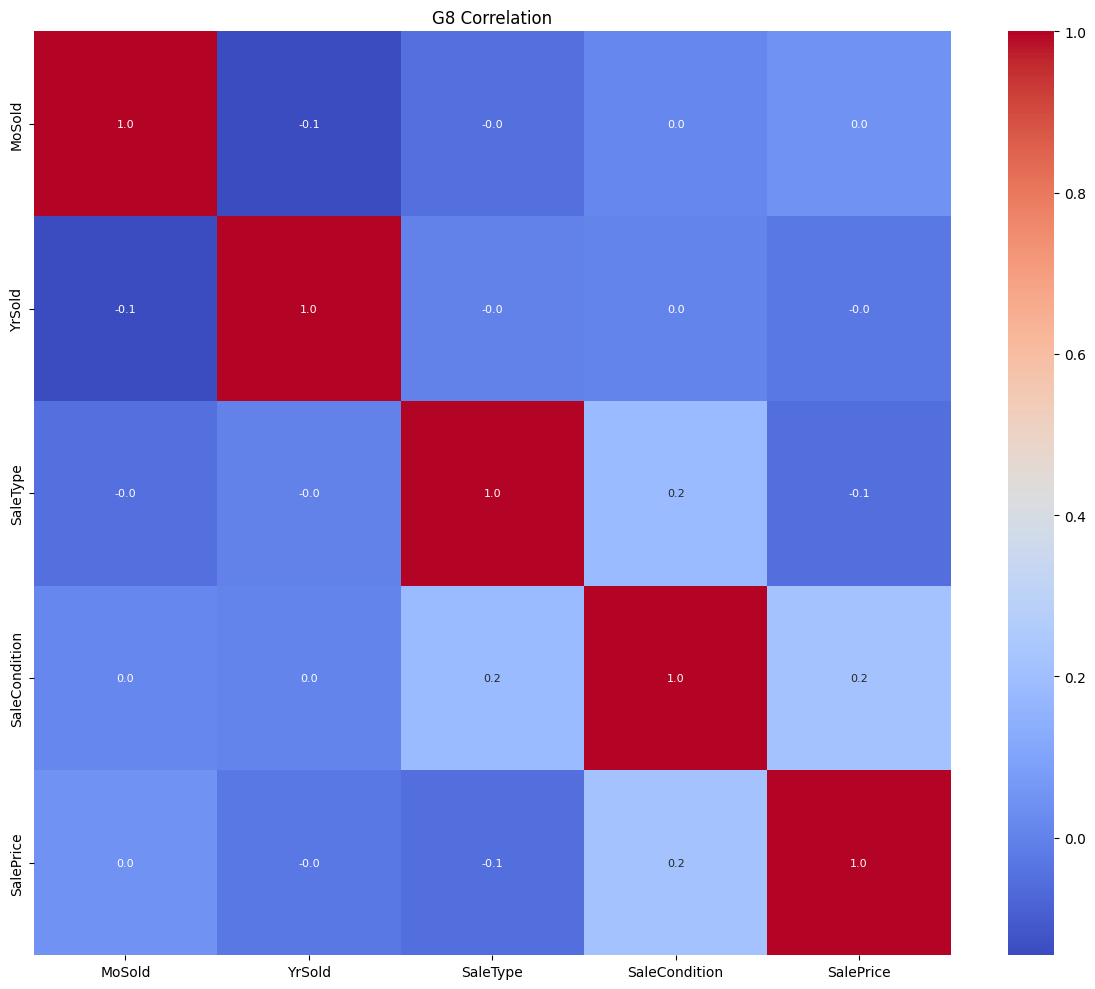

In [35]:
plt.figure(figsize=(12, 10))
sns.heatmap(G8.corr(), annot=True, cmap="coolwarm", fmt=".1f", annot_kws={"size": 8})
plt.title("G8 Correlation")
plt.tight_layout()
plt.show()

In [36]:
df=df.drop(["YrSold","MoSold"],axis=1)

In [37]:
df.shape

(1460, 56)

In [38]:
X = df.drop("SalePrice", axis=1)
Y = df["SalePrice"]
print(X.shape)
print(Y.shape)

(1460, 55)
(1460,)


In [386]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.23, random_state=35
)
print(X_train.shape)
print(X_test.shape)

(1124, 55)
(336, 55)


In [387]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [388]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LinearRegression())
])
pipe.fit(X_train, Y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [389]:
train_rmse = np.sqrt(mean_squared_error(Y_train, pipe.predict(X_train)))
test_rmse  = np.sqrt(mean_squared_error(Y_test,  pipe.predict(X_test)))
train_r2   = r2_score(Y_train, pipe.predict(X_train))
test_r2    = r2_score(Y_test,  pipe.predict(X_test))

In [390]:
print("linear algebra results below:")
print(f"Train RMSE:", train_rmse)
print(f"Test  RMSE:",test_rmse)
print("Train R²",   train_r2)
print("Test  R²",test_r2)

linear algebra results below:
Train RMSE: 31082.069846266513
Test  RMSE: 35043.139386052855
Train R² 0.8420209860566802
Test  R² 0.8229075823880871


In [391]:
from sklearn.ensemble import RandomForestRegressor

In [441]:
rf = RandomForestRegressor(
    n_estimators=21,   # many trees
    max_depth=16,       # medium depth
    min_samples_leaf=6, # balanced
    max_features=0.7,   # use most features
    random_state=500000000
)
rf.fit(X_train, Y_train)

RandomForestRegressor(max_depth=16, max_features=0.7, min_samples_leaf=6,
                      n_estimators=21, random_state=500000000)

In [442]:
rf_train_rmse = np.sqrt(mean_squared_error(Y_train, rf.predict(X_train)))
rf_test_rmse  = np.sqrt(mean_squared_error(Y_test,  rf.predict(X_test)))
rf_train_r2   = r2_score(Y_train, rf.predict(X_train))
rf_test_r2    = r2_score(Y_test,  rf.predict(X_test))

In [443]:
print("random forest below :")
print(f"Train RMSE:",rf_train_rmse)
print(f"Test  RMSE:",rf_test_rmse)
print(f"Train R²:" ,  rf_train_r2)
print(f"Test  R²: " , rf_test_r2)

random forest below :
Train RMSE: 23548.694508399116
Test  RMSE: 30722.679452897682
Train R²: 0.9093196461482956
Test  R²:  0.8638830735867562


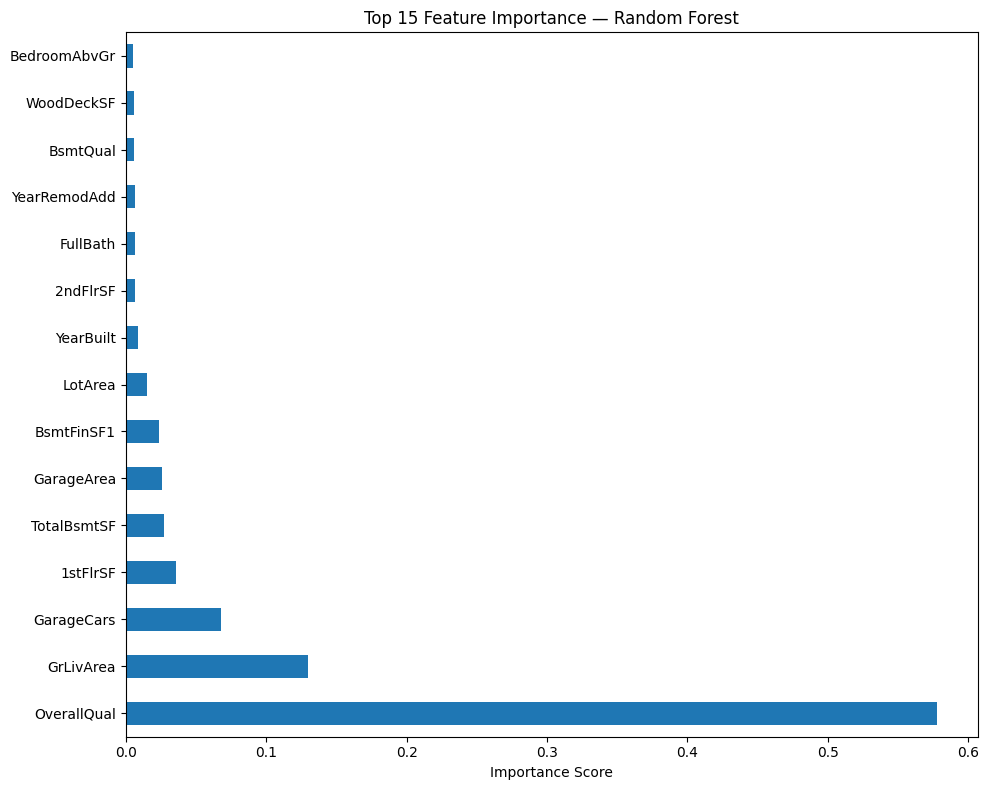

In [353]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(15).plot(kind="barh", figsize=(10, 8))
plt.title("Top 15 Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

##### random forest is best than linear regression